In [3]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, auc, accuracy_score,  classification_report, precision_recall_curve, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_score, train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn import metrics
from sklearn.calibration import calibration_curve
from xgboost import XGBClassifier

In [4]:
df_sissi = pd.DataFrame(pd.read_excel("C:/bla/Waste/MA/Data/SISSIz_Data_di_Excel/sissi.xlsx"))
df_sissiz_mono = pd.DataFrame(pd.read_excel("C:/bla/Waste/MA/Data/SISSIz_Data_di_Excel/sissiz_mono.xlsx"))
df_sissiz_di = pd.DataFrame(pd.read_excel("C:/bla/Waste/MA/Data/SISSIz_Data_di_Excel/sissiz_di.xlsx"))
df_multiperm_mono = pd.DataFrame(pd.read_excel("C:/bla/Waste/MA/Data/SISSIz_Data_di_Excel/multiperm_mono.xlsx"))
df_multiperm_di = pd.DataFrame(pd.read_excel("C:/bla/Waste/MA/Data/SISSIz_Data_di_Excel/multiperm_di.xlsx"))
df_aln_shuffle = pd.DataFrame(pd.read_excel("C:/bla/Waste/MA/Data/SISSIz_Data_di_Excel/alifoldz.xlsx"))

In [5]:
# df_sissiz_mono = pd.DataFrame(pd.read_excel('D:/Masterarbeit_Daten/Data/SISSIz_Data_di_Excel/sissiz_mono.xlsx'))
# df_sissiz_di = pd.DataFrame(pd.read_excel('D:/Masterarbeit_Daten/Data/SISSIz_Data_di_Excel/sissiz_di.xlsx'))
# df_multiperm_mono = pd.DataFrame(pd.read_excel('D:/Masterarbeit_Daten/Data/SISSIz_Data_di_Excel/multiperm_mono.xlsx'))
# df_multiperm_di = pd.DataFrame(pd.read_excel('D:/Masterarbeit_Daten/Data/SISSIz_Data_di_Excel/multiperm_di.xlsx'))
# df_aln_shuffle = pd.DataFrame(pd.read_excel('D:/Masterarbeit_Daten/Data/SISSIz_Data_di_Excel/alifoldz.xlsx'))

In [18]:
df_sissiz_mono_combined = pd.concat([df_sissi, df_sissiz_mono], ignore_index=True)

In [19]:
def plot_confusion_matrix(cm, title, ax=None):
    group_names = ['True Neg', 'False Pos', 'False Neg', 'True Pos']
    group_counts = ["{0:0.0f}".format(value) for value in cm.flatten()]
    group_percentages = ["{0:.2%}".format(value) for value in cm.flatten() / np.sum(cm)]
    labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in zip(group_names, group_counts, group_percentages)]
    labels = np.asarray(labels).reshape(2, 2)

    sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', ax=ax)
    ax.set_title(title)
    ax.set_xlabel('\nPredicted Values')
    ax.set_ylabel('Actual Values')
    ax.xaxis.set_ticklabels(['False', 'True'])
    ax.yaxis.set_ticklabels(['False', 'True'])

In [20]:
def plot_roc_curve(fper, tper, title, ax=None):
    roc_auc = auc(fper, tper)
    ax.plot(fper, tper, color='red', label=f'ROC curve (area = {roc_auc:0.2f})')
    ax.plot([0, 1], [0, 1], color='green', linestyle='--', label='No Skill')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(title)
    ax.legend()

In [ ]:
def logistic_regression_pipeline(data, title, target_column='z-score calculated from 7. 8. and 9.', threshold=-4, class_weights={0: 1, 1: 3}):

    # Schritt 1: Features und Zielvariable aufteilen
    X = data[['Mean Pairwise Identity (MPI) of the input alignment',
              'Average MPI of the sampled alignments.',
              'Standard deviation of the MPIs of the sampled alignments',
              'Structural Conservation Index (SCI)',
              'GC-Content',
              'RNAalifold consensus Minimum Free Energy (MFE) of the original alignment.',
              'Average consensus MFE in the sampled alignments',
              'Standard deviation of the consensus MFE in the sampled alignments']]
    

    # Standardisierung des z-scores
    # data["z-score"] = (data[target_column] - data[target_column].mean()) / data[target_column].std()
    data["label"] = np.where(data["z-score calculated from 7. 8. and 9."] > threshold, 1, 0)

    # Erstellen der 'label' Spalte mit dem Schwellenwert
    y = data["label"]

    # Splitte in Training- und Testdaten
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)
    
    print("X_train:", X_train.shape)
    print("y_train:", y_train.shape)
    print("X_test:", X_test.shape)
    print("y_test:", y_test.shape)
    print('y_train', y_train.value_counts())
    print('y_test', y_test.value_counts())

    # Schritt 2: Logistische Regression trainieren
    log_reg = LogisticRegression(class_weight=class_weights, max_iter=1000, random_state=0)
    log_reg.fit(X_train, y_train)

    # Schritt 3: Modellbewertung mit Cross-Validation
    scores = cross_val_score(log_reg, X_train, y_train, cv=10)
    print(f"Cross-validation scores: {scores}")
    print(f"Mean CV score: {scores.mean()}")

    # Schritt 4: Vorhersagen und Modell testen
    y_pred = log_reg.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    # Berechnung der Accuracy und False Negative Rate
    acc = accuracy_score(y_test, y_pred)
    print("Accuracy score: ", acc)
    print("False-Negative Rate: ", 1 - cm[1][0] / (cm[1][0] + cm[1][1]))

    # Schritt 5: ROC-Kurve und AUC berechnen
    y_test_prob = log_reg.predict_proba(X_test)[:, 1]
    fper, tper, thresholds = roc_curve(y_test, y_test_prob)
    auc_score = roc_auc_score(y_test, y_test_prob)
    print(f"AUC score: {auc_score}")
   
    # Erstelle Subplots für beide Plots
    fig, ax = plt.subplots(1, 2, figsize=(15, 7))  # 1 Zeile, 2 Spalten
    
    # Plot Confusion Matrix
    plot_confusion_matrix(cm, title, ax=ax[0])

    # Plot ROC Curve
    plot_roc_curve(fper, tper, title, ax=ax[1])

    # Zeige die Plots an
    plt.tight_layout()  # Optional: Verbessert das Layout
    plt.show()

X_train: (70070, 8)
y_train: (70070,)
X_test: (30030, 8)
y_test: (30030,)
y_train label
1    70005
0       65
Name: count, dtype: int64
y_test label
1    29992
0       38
Name: count, dtype: int64
Cross-validation scores: [0.99971457 1.         1.         1.         1.         0.99985729
 1.         1.         1.         1.        ]
Mean CV score: 0.9999571856714713
Accuracy score:  1.0
False-Negative Rate:  1.0
AUC score: 1.0


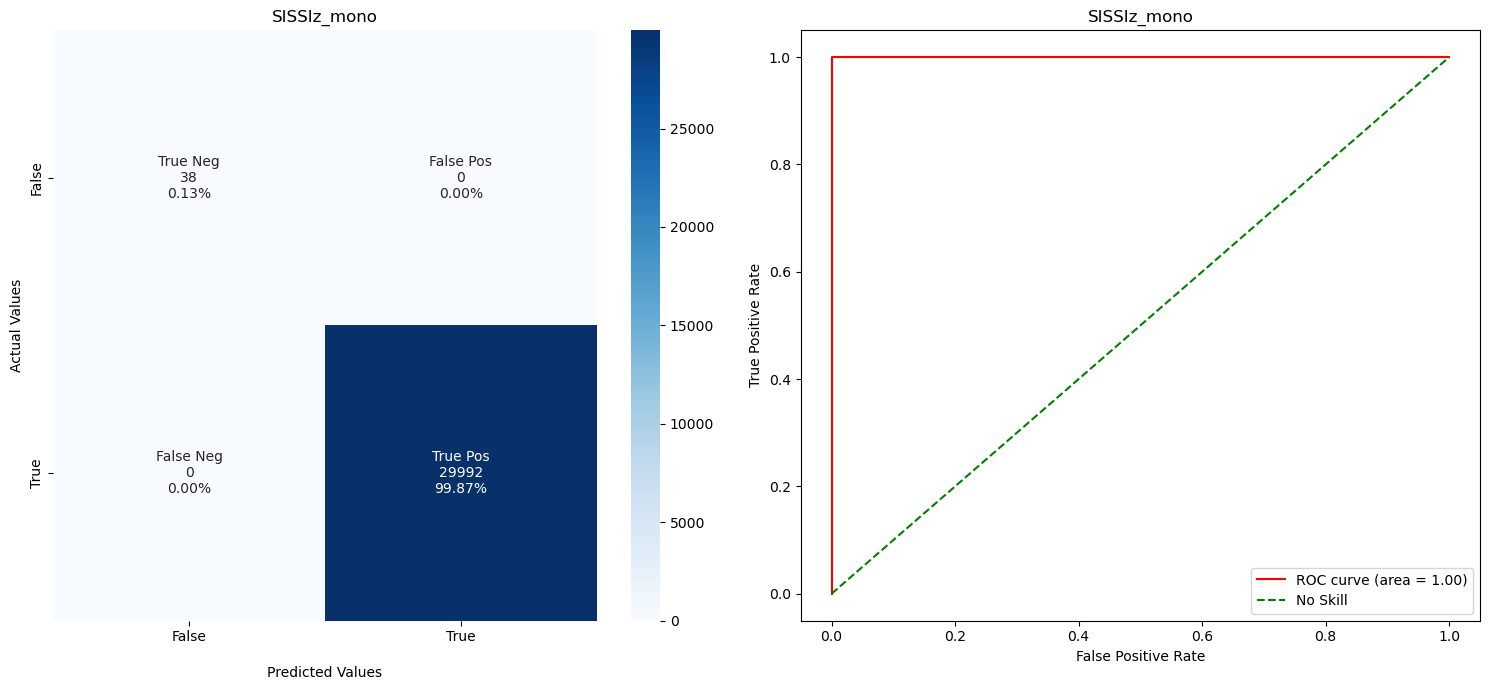

In [24]:
logistic_regression_pipeline(df_sissiz_mono_combined, 'SISSIz_mono')